Parte 1 · Personalización de gráficos (ventas_mensuales.csv)



Ejercicio 1.1 Crea el gráfico de barras "por defecto" (sin ningún ajuste) de ingresos por mes, usando matplotlib. Muéstraselo a alguien que no vio los datos y pídele que te diga, en cinco segundos, cuál fue el mes más fuerte. ¿Pudo hacerlo?

Ejercicio 1.2 Ahora rehaz el mismo gráfico resaltando con color solo el mes de mayor ingreso, con un título que sea una afirmación (no "Ingresos por mes"), y sin los bordes superior y derecho. Repite la prueba del ejercicio anterior.

Ejercicio 1.3 Rehaz el gráfico del ejercicio 1.2, pero esta vez usando sns.barplot() en lugar de ax.bar(). Compara cuánto código necesitaste en cada caso para llegar a un resultado similar.

Ejercicio 1.4 (desafío) Agrega una anotación (ax.annotate) que marque el valor exacto del mes pico directamente sobre la barra, en lugar de obligar a leerlo en el eje Y.

Parte 2 · Buenas prácticas de visualización



Ejercicio 2.1 Con ventas_por_categoria.csv: antes de graficar, decide si conviene un gráfico de torta o una barra horizontal ordenada. Justifica en una oración tu elección, según cuántas categorías hay y qué tan distintos son los valores entre sí.

Ejercicio 2.2 Crea el gráfico que elegiste en el ejercicio 2.1 usando sns.barplot(). Después crea también el gráfico de torta con matplotlib (ax.pie()), aunque lo hayas descartado. Compara cuál se lee más rápido.

Ejercicio 2.3 Con variacion_mensual.csv: crea el gráfico de variación porcentual mes a mes usando una paleta divergente (dos colores según el signo) y una línea de referencia en cero. ¿Qué mes se aleja más del resto?

Ejercicio 2.4 (desafío) Toma el gráfico del ejercicio 2.3 y rehazlo intencionalmente "mal": con un eje Y que no comience en cero, para observar cómo cambia la percepción de las diferencias entre meses. Compara ambas versiones. ¿En qué situación real ese segundo gráfico resultaría directamente engañoso?

Parte 3 · Data Storytelling (ventas_historico_3anios.csv)



Ejercicio 3.1 Antes de revisar el dataset: si el equipo comercial te pregunta "¿conviene reforzar el stock para diciembre?", escribe el contexto y el hallazgo (dos o tres oraciones cada uno) que imaginas que vas a encontrar, sin haber mirado todavía los datos.

Ejercicio 3.2 Ahora revisa el dataset. Crea el gráfico de líneas superpuestas por año (como el del artículo) y confirma o corrige tu hipótesis del ejercicio anterior.

Ejercicio 3.3 Escribe las cuatro partes completas —contexto, hallazgo, evidencia (haciendo referencia al gráfico del ejercicio 3.2), recomendación— como si fuera el texto de una diapositiva. La recomendación debe ser una acción concreta, no solo una observación.

Ejercicio 3.4 (desafío, integrador) Elige cualquiera de los tres datasets de esta carpeta y arma el recorrido completo desde cero: pregunta de negocio → tipo de gráfico correcto → gráfico personalizado (con matplotlib o seaborn, a tu elección) → las cuatro partes de la historia. Este es, en miniatura, el ejercicio que vas a repetir en cualquier análisis real que entregues de ahora en adelante.



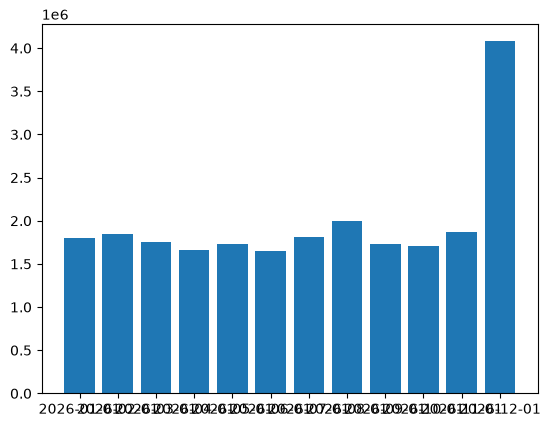

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # La dejamos importada para los siguientes ejercicios

# 1. Cargamos el dataset
df_mensual = pd.read_csv('ventas_mensuales.csv')

# 2. Creamos el gráfico de barras por defecto con matplotlib
fig, ax = plt.subplots()
ax.bar(df_mensual['mes'], df_mensual['ingresos'])

# Mostramos el gráfico
plt.show()

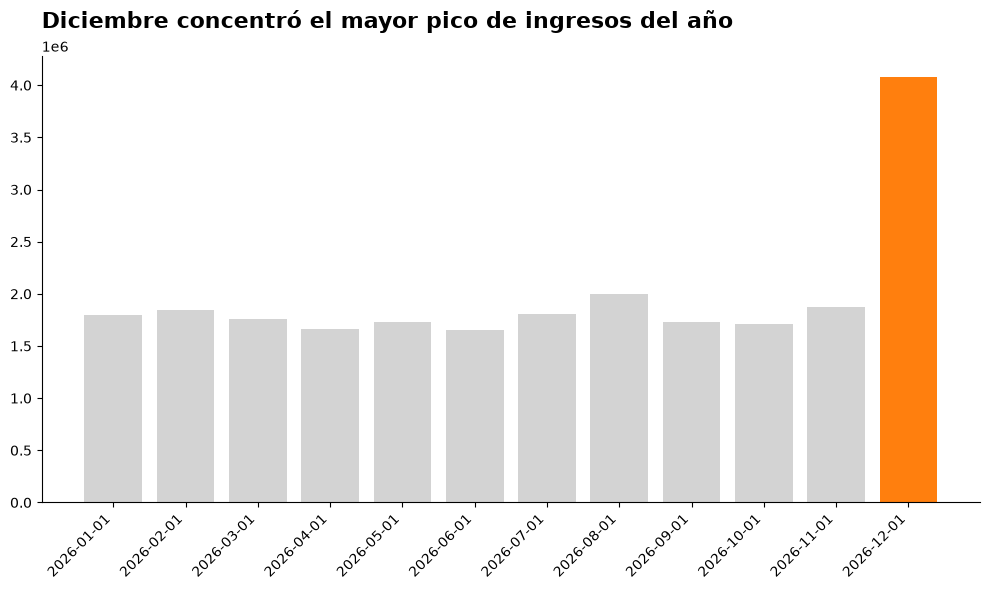

In [2]:
# Creamos una figura un poco más ancha para que respiren los datos
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Identificamos el valor máximo para destacarlo
max_ingreso = df_mensual['ingresos'].max()

# 2. Creamos una lista de colores: gris neutro para casi todos, naranja (o tu color favorito) para el máximo
colores = ['#d3d3d3' if valor < max_ingreso else '#ff7f0e' for valor in df_mensual['ingresos']]

# 3. Dibujamos el gráfico aplicando nuestros colores
ax.bar(df_mensual['mes'], df_mensual['ingresos'], color=colores)

# 4. STORYTELLING: Un título que es una afirmación clara, no una descripción aburrida
ax.set_title('Diciembre concentró el mayor pico de ingresos del año', 
             loc='left', fontsize=16, fontweight='bold', pad=20)

# 5. BUENAS PRÁCTICAS: Eliminamos los bordes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. Solución al amontonamiento: rotamos las etiquetas del eje X
plt.xticks(rotation=45, ha='right')

# Ajustamos automáticamente los márgenes para que nada quede cortado
plt.tight_layout()
plt.show()

C:\Users\Giovanni\AppData\Local\Temp\ipykernel_5112\2111764567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mensual, x='mes', y='ingresos', palette=colores, ax=ax)


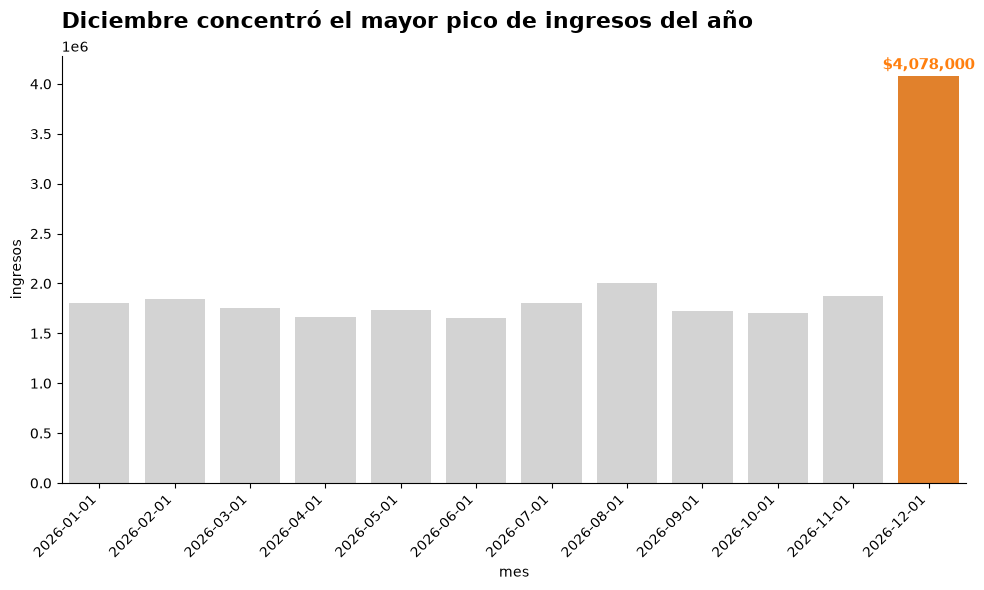

In [3]:
# Configuramos la figura
fig, ax = plt.subplots(figsize=(10, 6))

# Lógica de colores (igual que antes)
max_ingreso = df_mensual['ingresos'].max()
colores = ['#d3d3d3' if valor < max_ingreso else '#ff7f0e' for valor in df_mensual['ingresos']]

# EJERCICIO 1.3: Usamos Seaborn en lugar de matplotlib
# Nota como Seaborn lee directamente los nombres de las columnas del DataFrame
sns.barplot(data=df_mensual, x='mes', y='ingresos', palette=colores, ax=ax)

# Título
ax.set_title('Diciembre concentró el mayor pico de ingresos del año', 
             loc='left', fontsize=16, fontweight='bold', pad=20)

# El truco mágico de Seaborn para quitar los bordes superior y derecho (reemplaza las dos líneas de matplotlib)
sns.despine()

plt.xticks(rotation=45, ha='right')

# EJERCICIO 1.4 (Desafío): Anotación
# Buscamos la posición (índice X) y el valor exacto (Y) del pico
indice_max = df_mensual['ingresos'].idxmax()
valor_max = df_mensual['ingresos'].max()

# Formateamos el número para que se vea como moneda (ej: $4,000,000)
texto_etiqueta = f"${valor_max:,.0f}"

# Agregamos el texto directamente en el gráfico
ax.annotate(texto_etiqueta, 
            xy=(indice_max, valor_max), # Las coordenadas donde apunta
            xytext=(0, 5),              # Lo movemos 5 puntitos hacia arriba para que no pise la barra
            textcoords="offset points", 
            ha='center',                # Centrado horizontalmente
            fontweight='bold', 
            fontsize=11,
            color='#ff7f0e')            # Del mismo color que la barra

# Ajustar y mostrar
plt.tight_layout()
plt.show()

In [4]:
df_categorias = pd.read_csv('ventas_por_categoria.csv')
print(df_categorias)

      categoria  ingresos
0   electronica   9800000
1  indumentaria   4100000
2         hogar   3600000
3      deportes   2900000
4      juguetes   1450000
5        libros    980000


Elección: Gráfico de barras horizontales ordenadas.
Justificación: Porque al tener 6 categorías con valores relativamente cercanos entre sí (como indumentaria, hogar y deportes), el ojo humano compara mucho mejor las longitudes rectas de unas barras ordenadas que los ángulos de un gráfico de torta.

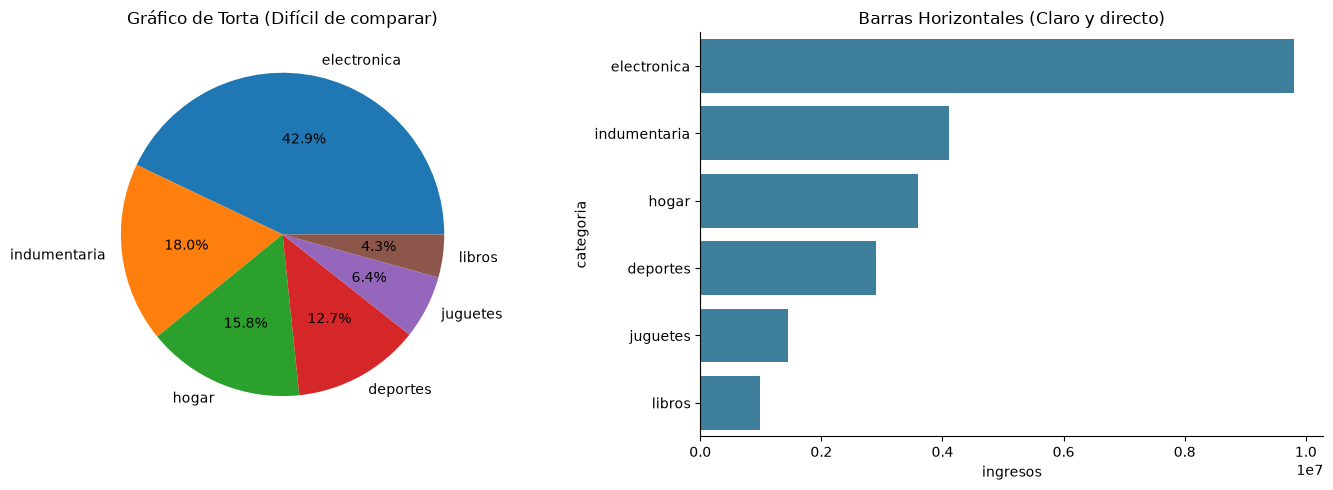

In [5]:
# Preparamos una figura con dos espacios (1 fila, 2 columnas)
fig, (ax_torta, ax_barras) = plt.subplots(1, 2, figsize=(14, 5))

# 1. El gráfico de Torta (Descartado)
ax_torta.pie(df_categorias['ingresos'], labels=df_categorias['categoria'], autopct='%1.1f%%')
ax_torta.set_title("Gráfico de Torta (Difícil de comparar)")

# 2. El gráfico de Barras Horizontales (El ganador)
# Como la tabla ya está ordenada de mayor a menor en tu CSV, Seaborn la grafica directo
sns.barplot(data=df_categorias, x='ingresos', y='categoria', color='#2E86AB', ax=ax_barras)
ax_barras.set_title("Barras Horizontales (Claro y directo)")
sns.despine(ax=ax_barras) # Quitamos bordes sucios

plt.tight_layout()
plt.show()

In [9]:
df_variacion = pd.read_csv('variacion_mensual.csv')
print(df_variacion.columns)

Index(['mes', 'variacion_pct'], dtype='str')


C:\Users\Giovanni\AppData\Local\Temp\ipykernel_5112\2802375173.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  x=pd.to_datetime(df_variacion['mes']).dt.strftime('%b'),
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_5112\2802375173.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


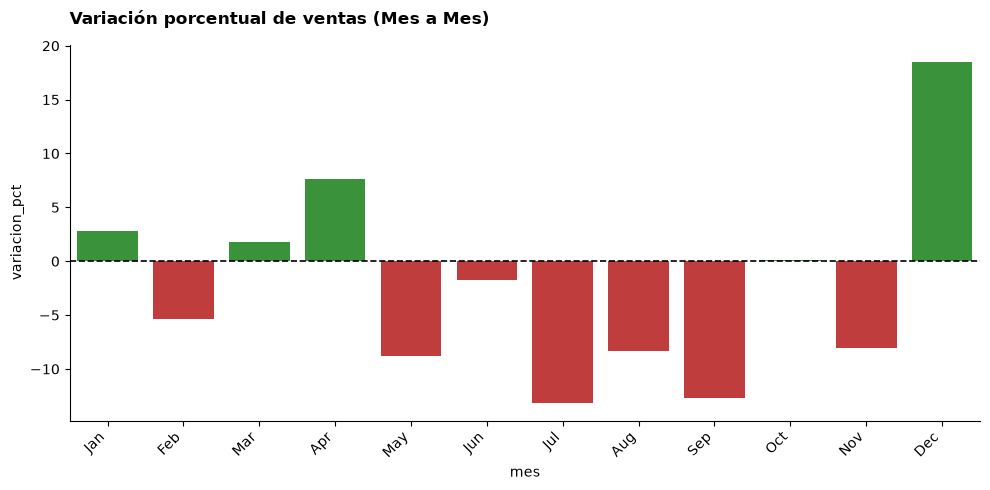

In [11]:
## 1. Cargamos el dataset
df_variacion = pd.read_csv('variacion_mensual.csv')

# 2. Creamos la figura
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Lógica de colores (Ajustado a 'variacion_pct')
colores_divergentes = ['#2ca02c' if valor > 0 else '#d62728' for valor in df_variacion['variacion_pct']]

# 4. Creamos el gráfico de barras usando el nombre correcto
sns.barplot(
    data=df_variacion, 
    x=pd.to_datetime(df_variacion['mes']).dt.strftime('%b'), 
    y='variacion_pct',  # ¡Aquí está la corrección principal!
    palette=colores_divergentes, 
    ax=ax
)

# 5. La línea de referencia en el CERO
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

# 6. Mejoras visuales
ax.set_title("Variación porcentual de ventas (Mes a Mes)", loc='left', fontweight='bold', pad=15)
sns.despine()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

si conviene mejorar el stock así se prepara para la venta de diciembre

In [14]:
df_historico = pd.read_csv('ventas_historico_3anios.csv')
print(df_historico.columns)

Index(['mes', 'ingresos'], dtype='str')


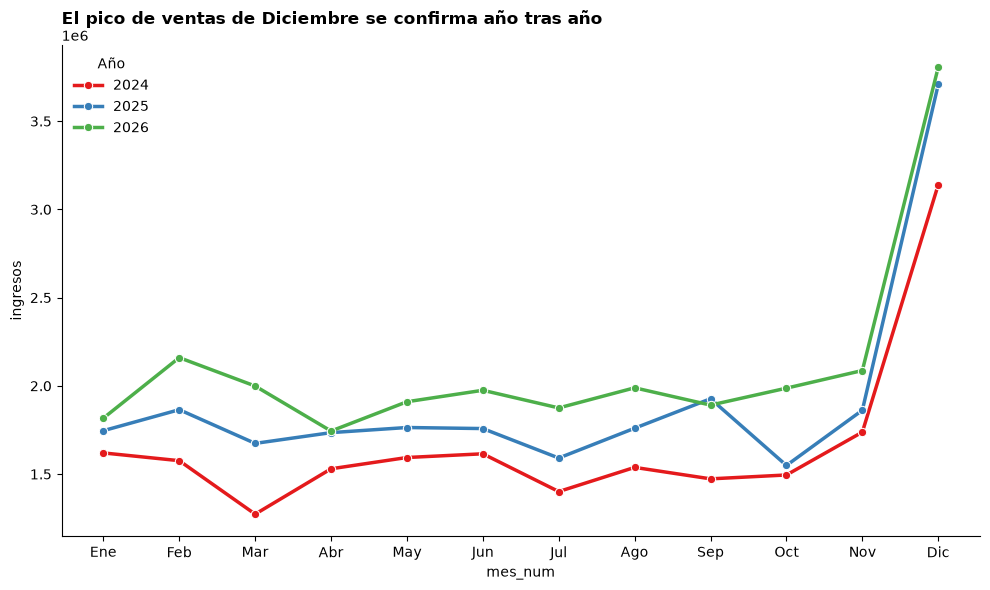

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos el dataset histórico
df_historico = pd.read_csv('ventas_historico_3anios.csv', encoding='utf-8-sig')
df_historico.columns = df_historico.columns.str.strip()

# 2. Convertimos la columna 'mes' a formato fecha (datetime)
df_historico['fecha_dt'] = pd.to_datetime(df_historico['mes'])

# Extraemos el número de mes (1 al 12) y el año para poder superponer las líneas
df_historico['mes_num'] = df_historico['fecha_dt'].dt.month
df_historico['año'] = df_historico['fecha_dt'].dt.year

# 3. Configuramos la figura
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Creamos el gráfico de líneas superpuestas (hue='año' separa las líneas)
sns.lineplot(
    data=df_historico, 
    x='mes_num', 
    y='ingresos', 
    hue='año', 
    marker='o', # Pone marcadores circulares en cada mes
    palette='Set1', # Paleta de colores distintiva
    linewidth=2.5,
    ax=ax
)

# 5. Aplicamos nuestras buenas prácticas de diseño y storytelling
ax.set_title("El pico de ventas de Diciembre se confirma año tras año", loc='left', fontweight='bold', pad=15)
sns.despine()

# Reemplazamos los números fríos del eje X por los nombres de los meses
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.xticks(ticks=range(1, 13), labels=meses_nombres)

# Limpiamos la leyenda
plt.legend(title='Año', frameon=False)

plt.tight_layout()
plt.show()